<a href="https://colab.research.google.com/github/gideonadeti/learning-machine-learning/blob/main/Machine_Learning_Fundamentals_Feature_Engineering_and_Extraction_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Run this cell to install SDV and ensure imbalanced-learn is available
!pip install sdv imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print("Environment successfully set up!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 7.7 MB/s eta 0:00:00
Environment successfully set up!


In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# We use the Breast Cancer dataset because it features continuous variables and clear target classes
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

# Split the dataset: 80% Training, 20% Testing
# random_state ensures reproducibility, stratify keeps class proportions intact
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(# Output dimensions to verify split
    f"Training features shape: {X_train.shape}\n"
    f"Testing features shape: {X_test.shape}"
)

Training features shape: (455, 30)
Testing features shape: (114, 30)


In [3]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 1. Min-Max Scaling
# We fit only on the training set to prevent data leakage, then transform both train and test
min_max_scaler = MinMaxScaler()
X_train_minmax = min_max_scaler.fit_transform(X_train)
X_test_minmax = min_max_scaler.transform(X_test)

# 2. Z-Score Standardization
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

# Convert to DataFrame for quick visualization
sample_col_idx = 0  # Look at the first feature: 'mean radius'
print(f"Original Mean: {X_train.iloc[:, sample_col_idx].mean():.2f} | Std: {X_train.iloc[:, sample_col_idx].std():.2f}")
print(f"Min-Max Range: {X_train_minmax[:, sample_col_idx].min()} to {X_train_minmax[:, sample_col_idx].max()}")
print(f"Standardized Mean: {X_train_std[:, sample_col_idx].mean():.2f} | Std: {X_train_std[:, sample_col_idx].std():.2f}")

Original Mean: 14.07 | Std: 3.50
Min-Max Range: 0.0 to 1.0
Standardized Mean: -0.00 | Std: 1.00


In [4]:
# Compute pairwise correlation matrix
corr_matrix = pd.DataFrame(X_train_std, columns=X_train.columns).corr().abs()

# Select upper triangle of correlation matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.90
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]

X_train_filtered = pd.DataFrame(X_train_std, columns=X_train.columns).drop(columns=to_drop)
print(f"Filter Method: Dropped {len(to_drop)} highly correlated features. Remaining: {X_train_filtered.shape[1]}")

Filter Method: Dropped 10 highly correlated features. Remaining: 20


In [5]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Use Logistic Regression as the estimator to rank features
estimator = LogisticRegression(max_iter=1000, random_state=42)
# Select the top 10 most predictive features
rfe = RFE(estimator=estimator, n_features_to_select=10, step=1)
rfe.fit(X_train_std, y_train)

# Filter the training set
X_train_rfe = X_train_std[:, rfe.support_]
print(f"Wrapper Method (RFE): Selected {X_train_rfe.shape[1]} features.")

Wrapper Method (RFE): Selected 10 features.


In [6]:
from sklearn.linear_model import LassoCV

# LassoCV automatically finds the best regularization strength (alpha) via cross-validation
lasso = LassoCV(cv=5, random_state=42).fit(X_train_std, y_train)

# Count how many coefficients are exactly zero
eliminated_features = np.sum(lasso.coef_ == 0)
print(f"Embedded Method (LASSO): Penalized {eliminated_features} out of {X_train_std.shape[1]} features to 0.")

Embedded Method (LASSO): Penalized 7 out of 30 features to 0.


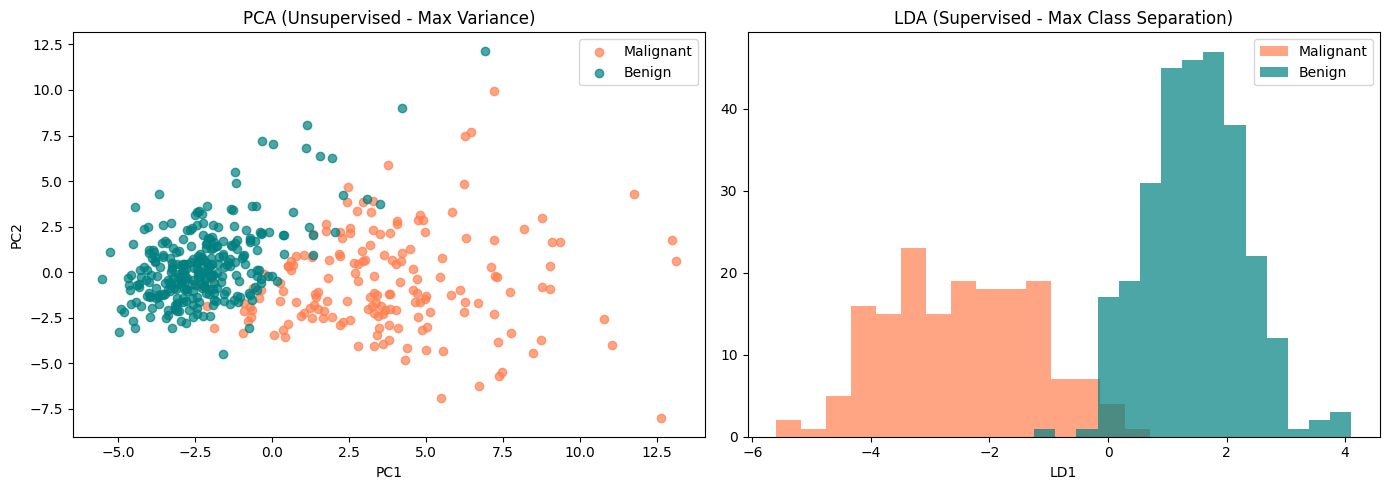

In [7]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# PCA - projects data into the top 2 components of highest variance
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std)

# LDA - projects data down by maximizing class separation (max components = n_classes - 1)
lda = LinearDiscriminantAnalysis(n_components=1)
X_train_lda = lda.fit_transform(X_train_std, y_train)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA Plot
axes[0].scatter(X_train_pca[y_train==0, 0], X_train_pca[y_train==0, 1], label='Malignant', alpha=0.7, c='coral')
axes[0].scatter(X_train_pca[y_train==1, 0], X_train_pca[y_train==1, 1], label='Benign', alpha=0.7, c='teal')
axes[0].set_title('PCA (Unsupervised - Max Variance)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# LDA Plot
axes[1].hist(X_train_lda[y_train==0], bins=15, label='Malignant', alpha=0.7, color='coral')
axes[1].hist(X_train_lda[y_train==1], bins=15, label='Benign', alpha=0.7, color='teal')
axes[1].set_title('LDA (Supervised - Max Class Separation)')
axes[1].set_xlabel('LD1')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from collections import Counter

# Let's create an artificial highly-imbalanced dataset from our data
X_imb = X_train_std[:150]
y_imb = y_train[:150]
print(f"Original Imbalanced Distribution: {Counter(y_imb)}")

# 1. Upsampling with SMOTE
smote = SMOTE(random_state=42)
X_resampled_up, y_resampled_up = smote.fit_resample(X_imb, y_imb)
print(f"SMOTE Over-sampled Distribution:   {Counter(y_resampled_up)}")

# 2. Downsampling with NearMiss
nearmiss = NearMiss(version=1)
X_resampled_down, y_resampled_down = nearmiss.fit_resample(X_imb, y_imb)
print(f"NearMiss Under-sampled Distribution: {Counter(y_resampled_down)}")

Original Imbalanced Distribution: Counter({1: 93, 0: 57})
SMOTE Over-sampled Distribution:   Counter({1: 93, 0: 93})
NearMiss Under-sampled Distribution: Counter({0: 57, 1: 57})


In [9]:
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

# Prepare data for SDV (it requires a pandas DataFrame with real column names)
df_real = pd.DataFrame(X_train_std[:, :4], columns=X_train.columns[:4])
df_real['target'] = y_train.values

# 1. Auto-detect schema metadata from the data frame
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_real)

# 2. Instantiate and fit the synthesizer
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(df_real)

# 3. Generate a synthetic version of our training dataset
synthetic_data = synthesizer.sample(num_rows=200)

print("Original Data Statistics:")
print(df_real.describe().loc[['mean', 'std']])
print("\nSynthetic Data Statistics (Privacy Preserved):")
print(synthetic_data.describe().loc[['mean', 'std']])

Original Data Statistics:
       mean radius  mean texture  mean perimeter     mean area    target
mean -4.337434e-15  2.240942e-15   -7.437274e-16  1.503071e-16  0.626374
std   1.001101e+00  1.001101e+00    1.001101e+00  1.001101e+00  0.484299

Synthetic Data Statistics (Privacy Preserved):
      mean radius  mean texture  mean perimeter  mean area    target
mean     0.049034  4.552410e+00        0.047421   0.045932  0.665000
std      1.122735  4.344818e-14        1.102357   1.054767  0.473175


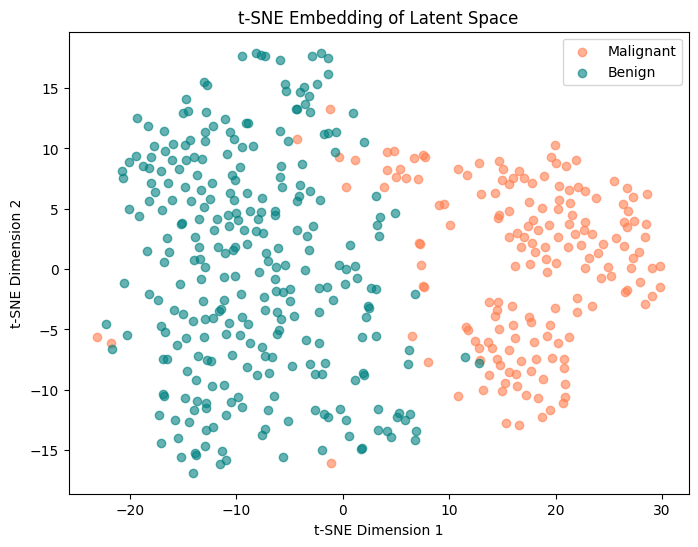

In [10]:
from sklearn.manifold import TSNE

# t-SNE is highly sensitive to perplexity (number of effective neighbors)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_train_std)

# Visualizing the lower-dimensional latent space manifold
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[y_train==0, 0], X_tsne[y_train==0, 1], color='coral', label='Malignant', alpha=0.6)
plt.scatter(X_tsne[y_train==1, 0], X_tsne[y_train==1, 1], color='teal', label='Benign', alpha=0.6)
plt.title("t-SNE Embedding of Latent Space")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.show()

In [14]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- SIMULATED PIPELINE ---
# Imagine a scenario where we are predicting customer churn
X_raw, y_raw = make_classification(n_samples=1000, n_features=20, random_state=42)
df = pd.DataFrame(X_raw, columns=[f'feature_{i}' for i in range(20)])
df['target'] = y_raw

# A data engineer decides to create a highly optimized engineered feature:
# They calculate the global mean of feature_1 group-by-target across the entire dataset
global_target_means = df.groupby('target')['feature_1'].transform('mean')
df['engineered_feature_score'] = df['feature_1'] + global_target_means

# Splitting data afterwards
X_challenge = df.drop(columns=['target'])
y_challenge = df['target']
X_tr, X_te, y_tr, y_te = train_test_split(X_challenge, y_challenge, test_size=0.3, random_state=42)

# Training a simple model
clf = RandomForestClassifier(random_state=42)
clf.fit(X_tr, y_tr)

# Testing
preds = clf.predict(X_te)
print("=============================")
print(f"CHALLENGE ACCURACY: {accuracy_score(y_te, preds) * 100:.2f}%")
print("=============================")

CHALLENGE ACCURACY: 95.33%


In [15]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- SIMULATED PIPELINE (FULLY PRODUCTION-SAFE) ---
X_raw, y_raw = make_classification(n_samples=1000, n_features=20, random_state=42)
df_features = pd.DataFrame(X_raw, columns=[f'feature_{i}' for i in range(20)])

# Let's create a categorical feature (e.g., 'customer_tier') to mimic a real scenario
df_features['customer_tier'] = np.random.choice(['Gold', 'Silver', 'Bronze'], size=1000)

# 1. Split data FIRST to completely isolate the test set
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    df_features, y_raw, test_size=0.3, random_state=42
)

# 2. Engineer feature ONLY using TRAINING data
train_df_temp = X_tr_raw.copy()
train_df_temp['target'] = y_tr

# Calculate the historical churn rate per 'customer_tier' USING ONLY THE TRAINING SET
tier_churn_rates = train_df_temp.groupby('customer_tier')['target'].mean()

# 3. Apply the mapping to both sets using the FEATURE, never the target label
X_tr = X_tr_raw.copy()
X_tr['tier_churn_risk'] = X_tr['customer_tier'].map(tier_churn_rates)
X_tr = X_tr.drop(columns=['customer_tier']) # Drop the string column so the model can train

X_te = X_te_raw.copy()
X_te['tier_churn_risk'] = X_te['customer_tier'].map(tier_churn_rates)
# If a tier in the test set wasn't in the training set, fill it with the global training mean
X_te['tier_churn_risk'] = X_te['tier_churn_risk'].fillna(train_df_temp['target'].mean())
X_te = X_te.drop(columns=['customer_tier'])

# Training
clf = RandomForestClassifier(random_state=42)
clf.fit(X_tr, y_tr)

# Testing (Notice we pass X_te, which has NO knowledge of y_te inside its features!)
preds = clf.predict(X_te)
print("=============================")
print(f"REALISTIC ACCURACY: {accuracy_score(y_te, preds) * 100:.2f}%")
print("=============================")

REALISTIC ACCURACY: 86.00%
